In [7]:
import pandas as pd 
import seaborn as sns
import os
from typing import Dict, List, Tuple, Optional
import anndata as ad 

In [5]:

data_path='/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0322_cetux_1_dir/filtered_annotated_saver_ribomito_CRC0322_cetux_1_log2_pc1_cpm.csv'
data=pd.read_csv(data_path,header=0,index_col=0).T

In [8]:
def strip_prefix_from_genes(
    df: pd.DataFrame,
    meta_cols: Tuple[str, ...] = ("cell_id","sample","trattamento"),
    sep: str = ":",
    on_duplicate: str = "first",  # "error" | "first" | "mean" | "sum" | "suffix"
) -> Tuple[pd.DataFrame, Dict[str, List[str]]]:
    """
    Rename gene columns by removing the prefix before `sep`.
    Handle duplicates according to `on_duplicate` policy.
    Returns: (df_out, dup_report) where dup_report maps gene -> original columns
    """
    df = df.copy()
    meta_cols = list(meta_cols)
    gene_cols = [c for c in df.columns if c not in meta_cols]

    # map old gene col -> symbol after sep
    new_names = {c: c.split(sep)[-1] for c in gene_cols}
    df_ren = df.rename(columns=new_names)

    # build duplicate report
    dup_report: Dict[str, List[str]] = {}
    counts = pd.Series([new_names[c] for c in gene_cols]).value_counts()
    dups = counts[counts > 1].index.tolist()
    if dups:
        for g in dups:
            dup_report[g] = [c for c in gene_cols if new_names[c] == g]

        if on_duplicate == "error":
            raise ValueError(f"Duplicate genes after renaming: {dup_report}")

        elif on_duplicate in ("mean","sum"):
            agg_func = np.nanmean if on_duplicate == "mean" else np.nansum
            gdf = df_ren.drop(columns=meta_cols, errors="ignore")
            # collapse duplicates by aggregating columns with same name
            collapsed = {}
            for g, _cols in dup_report.items():
                mask = gdf.columns == g
                if mask.sum() > 1:
                    collapsed[g] = agg_func(gdf.loc[:, mask].to_numpy(), axis=1)
                else:
                    collapsed[g] = gdf.loc[:, g].to_numpy()
            keep_mask = ~gdf.columns.duplicated(keep=False)
            gdf_unique = gdf.loc[:, keep_mask].copy()
            for g, vec in collapsed.items():
                gdf_unique[g] = vec
            df_out = pd.concat([df_ren.loc[:, meta_cols], gdf_unique], axis=1)

        elif on_duplicate == "first":
            cols_meta = list(meta_cols)
            cols_gene_unique = ~df_ren.columns.duplicated(keep="first")
            df_out = pd.concat([df_ren.loc[:, cols_meta],
                                df_ren.loc[:, cols_gene_unique & ~df_ren.columns.isin(cols_meta)]],
                               axis=1)
        elif on_duplicate == "suffix":
            seen = {}
            newcols = []
            for c in df_ren.columns:
                if c in meta_cols:
                    newcols.append(c); continue
                name = c
                if name not in seen:
                    seen[name] = 1
                    newcols.append(name)
                else:
                    newcols.append(f"{name}.{seen[name]}")
                    seen[name] += 1
            df_out = df_ren.copy()
            df_out.columns = newcols
        else:
            raise ValueError(f"Unsupported on_duplicate={on_duplicate}")
    else:
        df_out = df_ren

    # reorder: meta first
    gene_cols_new = [c for c in df_out.columns if c not in meta_cols]
    df_out = pd.concat([df_out.loc[:, meta_cols], df_out.loc[:, gene_cols_new]], axis=1)

    return df_out, dup_report

In [9]:
trattamento='cetux'
data['sample']='CRC0322_cetux'
data['cell_id']=data.index
data['trattamento']=trattamento
data.reset_index(drop=True,inplace=True)
df_clean, dup = strip_prefix_from_genes(data, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")

In [30]:
umap_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/umap_ingested/CRC0322_cetux_1_umap_ingested.csv'
umap=pd.read_csv(umap_path,index_col=0,header=0)

In [31]:
df_merged = umap.merge(df_clean, on="cell_id", how="inner")

In [33]:
df_merged

,cell_id,umap1,umap2,sample,trattamento,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,...,ADORA3,AL512428.1,TEX13C,C1orf232,TMEM275,AC004706.3,AL031777.2,KLF18,LBHD2,CENPVL2
0,AAACCCACACACCAGC.1,10.568197,15.299576,CRC0322_cetux,cetux,9.182038,1.290913,5.851694,4.409771,2.075592,...,0.0,0.0,0.0,0.0,0.0,0.402195,4.442139,0.0,0.0,0.0
1,AAACCCACACTGGCCA.1,13.096614,13.014298,CRC0322_cetux,cetux,8.954556,1.236142,6.162812,4.331284,2.004544,...,0.0,0.0,0.0,0.0,0.0,0.379911,4.475017,0.0,0.0,0.0
2,AAACCCAGTGTCTTCC.1,6.231649,6.070234,CRC0322_cetux,cetux,8.430824,1.181180,6.186498,4.239364,2.220954,...,0.0,0.0,0.0,0.0,0.0,0.358051,4.430529,0.0,0.0,0.0
3,AAACGAATCGAAGCCC.1,7.935926,13.353188,CRC0322_cetux,cetux,8.939527,1.116606,6.343033,4.245160,2.305453,...,0.0,0.0,0.0,0.0,0.0,0.369707,3.977334,0.0,0.0,0.0
4,AAACGCTGTCTGCATA.1,6.771976,13.182657,CRC0322_cetux,cetux,9.529687,1.146387,6.312496,4.169142,2.295855,...,0.0,0.0,0.0,0.0,0.0,0.344472,4.667132,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461,TTTGGAGGTGACAGCA.1,13.123981,12.423493,CRC0322_cetux,cetux,9.124221,1.179459,6.185552,4.365009,2.599240,...,0.0,0.0,0.0,0.0,0.0,0.396411,5.390659,0.0,0.0,0.0
2462,TTTGGAGTCTTACTGT.1,8.676569,4.700631,CRC0322_cetux,cetux,8.618767,1.090597,6.519577,4.082380,3.397669,...,0.0,0.0,0.0,0.0,0.0,0.323113,3.134522,0.0,0.0,0.0
2463,TTTGGTTAGGCCGCTT.1,2.401569,9.717061,CRC0322_cetux,cetux,7.775874,1.353804,5.962774,4.552956,1.699259,...,0.0,0.0,0.0,0.0,0.0,0.602758,6.153526,0.0,0.0,0.0
2464,TTTGGTTCAAAGTATG.1,8.604410,5.670734,CRC0322_cetux,cetux,8.710958,1.090291,6.433637,4.071109,3.027050,...,0.0,0.0,0.0,0.0,0.0,0.322997,3.134012,0.0,0.0,0.0


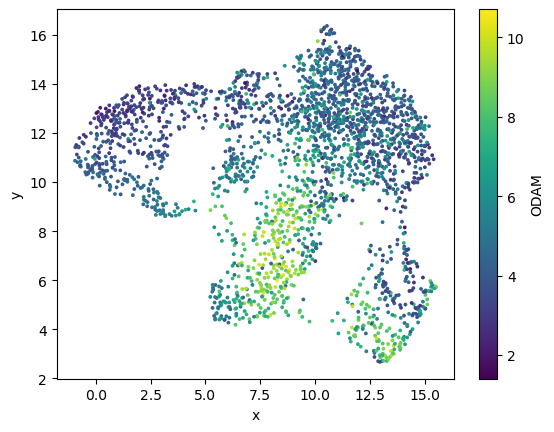

In [34]:
import matplotlib.pyplot as plt

plt.scatter(
    df_merged['umap1'],
    df_merged['umap2'],
    c=df_merged['ODAM'],
    cmap='viridis',s=3
)

plt.colorbar(label='ODAM')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


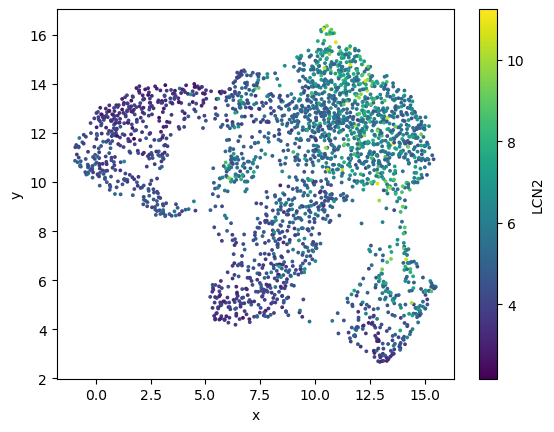

In [36]:
import matplotlib.pyplot as plt

plt.scatter(
    df_merged['umap1'],
    df_merged['umap2'],
    c=df_merged['LCN2'],
    cmap='viridis',s=3
)

plt.colorbar(label='LCN2')
plt.xlabel('x')
plt.ylabel('y')
plt.show()